# Two modulations

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import minisynth
import json
import utils
import h5py
import tqdm

from IPython.display import display, Audio

2025-08-20 15:21:00.991883: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-20 15:21:01.132558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-08-20 15:21:01.149388: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-08-20 15:21:01.156695: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-08-20 15:21:01.320774: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# all possible combinations of parameters 
# 
ranges = [3,3,3,3,6,3,3,]

def get_params():
    params = []
    for i in range(ranges[0]):
        for j in range(ranges[1]):
            for k in range(ranges[2]):
                for l in range(ranges[3]):
                    for m in range(ranges[4]):
                        for n in range(ranges[5]):
                            for o in range(ranges[6]):
                                params.append([i,j,k,l,m,n,o])
    return params

# combinations = get_params()

# # save to json
# with open('twomod-params.json', 'w') as f:
#     json.dump(combinations, f)



In [26]:
def linear_map(u, min_val, max_val):
    return min_val + u * (max_val - min_val)

def exp_map(u, min_val, max_val, k=2):
    return min_val + ((np.exp(k * u) - 1) / (np.exp(k) - 1)) * (max_val - min_val)

def load_repr(filename, i):
    with h5py.File(filename, 'r') as f:
        return f[str(i)][:]

In [27]:
synth = minisynth.MiniSynthSubtractive(duration=2.0)

base_values = {}

values = np.linspace(0, 1, 5)

params = synth.get_parameters()
for param_id, param in params.items():
    if param['scale'] == minisynth.Scale.LINEAR:
        base_values[param_id] = linear_map(values, param['range'][0], param['range'][1])
    elif param['scale'] == minisynth.Scale.LOGARITHMIC:
        base_values[param_id] = exp_map(values, param['range'][0], param['range'][1])

print(base_values)

{'base_freq': array([  50.        ,  146.45950789,  305.4943503 ,  567.69847777,
       1000.        ]), 'amp': array([0.        , 0.10153632, 0.26894142, 0.54494577, 1.        ]), 'filter_cutoff': array([ 200.        ,  687.37435564, 1490.91882258, 2815.73967717,
       5000.        ]), 'osc_shape': array([0.  , 0.25, 0.5 , 0.75, 1.  ])}


In [5]:
sine_zero_phase = np.cos(np.linspace(0, 2 * np.pi, 1000))/2+0.5
sine_half_phase = np.cos(np.linspace(0, 2 * np.pi, 1000) + np.pi/2)/2+0.5
sine_full_phase = np.cos(np.linspace(0, 2 * np.pi, 1000) + np.pi)/2+0.5

sines = [
    sine_zero_phase,
    sine_half_phase,
    sine_full_phase
]

In [6]:
PATH = 'twomod-params.json'

df = pd.read_json(PATH)

# # add header
df.columns = ['base_freq', 'amp', 'filter_cutoff', 'osc_shape', 'modulations', 'modulation_offset', 'modulation_balance']

display(df)

,base_freq,amp,filter_cutoff,osc_shape,modulations,modulation_offset,modulation_balance
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1
2,0,0,0,0,0,0,2
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...
4369,2,2,2,2,5,1,1
4370,2,2,2,2,5,1,2
4371,2,2,2,2,5,2,0
4372,2,2,2,2,5,2,1


In [6]:
modulations = [
    (0, 1),
    (0, 2),
    (0, 3),
    (1, 2),
    (1, 3),
    (2, 3)
]

balances = [
    (0.25, 0.75),
    (0.5, 0.5),
    (0.75, 0.25)
]

In [8]:
base_values

{'base_freq': array([  50.        ,  146.45950789,  305.4943503 ,  567.69847777,
        1000.        ]),
 'amp': array([0.        , 0.10153632, 0.26894142, 0.54494577, 1.        ]),
 'filter_cutoff': array([ 200.        ,  687.37435564, 1490.91882258, 2815.73967717,
        5000.        ]),
 'osc_shape': array([0.  , 0.25, 0.5 , 0.75, 1.  ])}

In [9]:
def get_entry(data, i):

    row = data.iloc[i]
    entry = {}
    base_keys = list(base_values.keys())

    log_indexes = [0, 1, 2]

    mod_sines = [
        sines[0]*balances[row['modulation_balance']][0],
        sines[row['modulation_offset']]*balances[row['modulation_balance']][1]
    ]

    for i in range(2):

        mod_index = modulations[row['modulations']][i]

        min = base_values[base_keys[mod_index]][row[mod_index]]
        max = base_values[base_keys[mod_index]][row[mod_index] + 2]

        if mod_index in log_indexes:
            mod = exp_map(mod_sines[i], min, max)
        else:
            mod = linear_map(mod_sines[i], min, max)
        entry[base_keys[mod_index]] = mod


    for key in base_keys:
        if key not in entry:
            entry[key] = [base_values[key][row[key]+1]]

    return entry


entry = get_entry(df, 4373)


/tmp/ipykernel_6128/3077369228.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min = base_values[base_keys[mod_index]][row[mod_index]]
/tmp/ipykernel_6128/3077369228.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max = base_values[base_keys[mod_index]][row[mod_index] + 2]


In [10]:
entry = get_entry(df, 3)

params = synth.get_parameters()

for key in entry:
    if key in params:
        params[key]['set'](entry[key])
    else:
        print(f"Parameter {key} not found in synth parameters.")

audio = synth.render()
display(Audio(audio, rate=44100))

/tmp/ipykernel_6128/3077369228.py:18: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  min = base_values[base_keys[mod_index]][row[mod_index]]
/tmp/ipykernel_6128/3077369228.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  max = base_values[base_keys[mod_index]][row[mod_index] + 2]


In [11]:
def generate_audio_representations():
    for repr in 'spectrum'.split():
        with h5py.File(f'twomod_reprs_{repr}.h5', 'w') as f:

            for i in tqdm.tqdm(range(len(df))):
                entry = get_entry(df, i)

                for key in entry:
                    if key in params:
                        params[key]['set'](entry[key])
                    else:
                        print(f"Parameter {key} not found in synth parameters.")

                audio = synth.render()
                audio = audio.copy()

                repr_data = utils.calc_representation(audio, repr=repr, sr=44100)

            # Save directly to file
                f.create_dataset(str(i), data=repr_data)

# generate_audio_representations()

In [12]:
df

,base_freq,amp,filter_cutoff,osc_shape,modulations,modulation_offset,modulation_balance
0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1
2,0,0,0,0,0,0,2
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...
4369,2,2,2,2,5,1,1
4370,2,2,2,2,5,1,2
4371,2,2,2,2,5,2,0
4372,2,2,2,2,5,2,1


In [13]:
df.iloc[0]["base_freq"]

0

In [14]:
correlation = []
for i in tqdm.tqdm(range(len(df))):
    entry = {}
    for repr_id in 'spectrum dac music2latent cqt mfcc'.split():
        for metric_id in 'magnitude distances cosine_similarity'.split():
            # load representation
            repr = load_repr(f'twomod_reprs_{repr_id}.h5', i)

            # calculate metric
            metric = utils.calc_metric(repr, metric=metric_id)
            metric = utils.smooth(metric, len(metric)//4)

            corr_1 = utils.calc_correlation(sines[0], metric)
            corr_2 = utils.calc_correlation(sines[df.iloc[i]['modulation_offset']], metric)

            corr_1_index = modulations[df.iloc[i]['modulations']][0]
            corr_2_index = modulations[df.iloc[i]['modulations']][1]

            corr_1_str = list(base_values.keys())[corr_1_index]
            corr_2_str = list(base_values.keys())[corr_2_index]

            entry[f'correlation_{corr_1_str}_{repr_id}_{metric_id}'] = corr_1
            entry[f'correlation_{corr_2_str}_{repr_id}_{metric_id}'] = corr_2
            
    correlation.append(entry)

correlation = pd.DataFrame(correlation)
correlation.to_csv('twomod_correlation.csv', index=False)

  0%|          | 0/4374 [00:00<?, ?it/s]

100%|██████████| 4374/4374 [02:44<00:00, 26.57it/s]


In [15]:
# df = pd.concat([df, correlation], axis=1)
# df.to_csv('twomod_correlation.csv', index=False)
# display(df.head())

,base_freq,amp,filter_cutoff,osc_shape,modulations,modulation_offset,modulation_balance,correlation_base_freq_spectrum_magnitude,correlation_amp_spectrum_magnitude,correlation_base_freq_spectrum_distances,...,correlation_osc_shape_dac_cosine_similarity,correlation_osc_shape_music2latent_magnitude,correlation_osc_shape_music2latent_distances,correlation_osc_shape_music2latent_cosine_similarity,correlation_osc_shape_cqt_magnitude,correlation_osc_shape_cqt_distances,correlation_osc_shape_cqt_cosine_similarity,correlation_osc_shape_mfcc_magnitude,correlation_osc_shape_mfcc_distances,correlation_osc_shape_mfcc_cosine_similarity
0,0,0,0,0,0,0,0,-0.752456,-0.752456,0.882980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,1,-0.777328,-0.777328,0.898006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0,0,0,0,2,-0.795140,-0.795140,0.908159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0,0,0,1,0,-0.224279,-0.839934,0.332469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,0,0,0,1,1,-0.210043,-0.841653,0.439202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df = pd.read_csv('twomod_correlation.csv')
df = df.abs()

display(df.head())

,base_freq,amp,filter_cutoff,osc_shape,modulations,modulation_offset,modulation_balance,correlation_base_freq_spectrum_magnitude,correlation_amp_spectrum_magnitude,correlation_base_freq_spectrum_distances,...,correlation_osc_shape_dac_cosine_similarity,correlation_osc_shape_music2latent_magnitude,correlation_osc_shape_music2latent_distances,correlation_osc_shape_music2latent_cosine_similarity,correlation_osc_shape_cqt_magnitude,correlation_osc_shape_cqt_distances,correlation_osc_shape_cqt_cosine_similarity,correlation_osc_shape_mfcc_magnitude,correlation_osc_shape_mfcc_distances,correlation_osc_shape_mfcc_cosine_similarity
0,0,0,0,0,0,0,0,0.752456,0.752456,0.882980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,0,0,0,0,1,0.777328,0.777328,0.898006,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,0,0,0,0,0,2,0.795140,0.795140,0.908159,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,0,0,0,0,1,0,0.224279,0.839934,0.332469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,0,0,0,0,1,1,0.210043,0.841653,0.439202,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


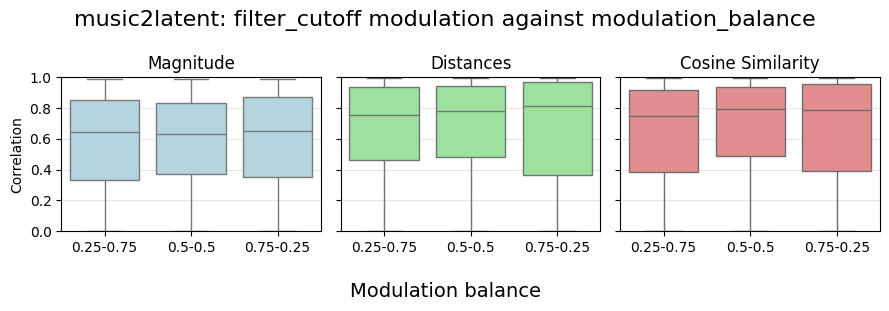

In [11]:
plot_tick_values = {
    "modulation_balance": ['0.25-0.75', '0.5-0.5', '0.75-0.25'],
    "modulation_offset": ['0', 'PI/2', 'PI'],
}

def plot_correlation_boxplots(df, repr, mod_target, x):
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))

    columns = [f'correlation_{mod_target}_{repr}_magnitude', f'correlation_{mod_target}_{repr}_distances', f'correlation_{mod_target}_{repr}_cosine_similarity']
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    titles = ['Magnitude', 'Distances', 'Cosine Similarity']

    index = 'base_freq amp filter_cutoff osc_shape'.split().index(mod_target)

    print(f'Index of {mod_target} in modulations: {index}')

    valid_mdoulations = [mod_index for mod_index in range(len(modulations)) if index in modulations[mod_index]]

    print(f'Valid modulations for {mod_target}: {valid_mdoulations}')
    positions = np.arange(len(plot_tick_values[x]))

    filtered_df = df

    for i, (col, color, title) in enumerate(zip(columns, colors, titles)):
        sns.boxplot(data=filtered_df, x=x, y=col, ax=axes[i], color=color)
        axes[i].set_title(title)
        axes[i].set_ylim(0,1)
        axes[i].set_xlabel("")
        axes[i].set_xticks(positions)
        axes[i].set_xticklabels(plot_tick_values[x])
        axes[i].set_ylabel('Correlation')
        axes[i].grid(True, alpha=0.3)

    axes[0].set_ylabel('Correlation')
    axes[1].label_outer()
    axes[2].label_outer()

    fig.supxlabel(" ".join(x.capitalize().split('_')), fontsize=14)

    plt.suptitle(f'{repr}: {mod_target} modulation against {x}', fontsize=16)
    plt.tight_layout()
    plt.show()


# example
repr = 'music2latent'
MOD_TARGET = 'filter_cutoff'
X = 'modulation_balance'


plot_correlation_boxplots(df, repr, MOD_TARGET, X)

In [33]:
param_names = list(base_values.keys())

modulations_names = [f'{param_names[couple[0]]}-{param_names[couple[1]]}' for couple in modulations]
modulations_names

['base_freq-amp',
 'base_freq-filter_cutoff',
 'base_freq-osc_shape',
 'amp-filter_cutoff',
 'amp-osc_shape',
 'filter_cutoff-osc_shape']

In [63]:
# summary table
# column should be the modulated parameters
# data is aggregated by representations and metrics, we don't care about modulated parameters
# this can all be done by manipulating the dataframe

summary = df.groupby(['modulations']).mean().reset_index()
summary['modulations'] = summary['modulations'].apply(lambda x: modulations_names[x])

# rename base_freq to 'frequency' in all string that contain it in correlation columns
summary.columns = summary.columns.str.replace('base_freq', 'frequency')
summary.columns = summary.columns.str.replace('cosine_similarity', 'similarity')

# rename correlation columns to parameter representations metric with a for loop by splitting
for col in summary.columns:
    if 'correlation_' in col:
        parts = col.split('_')
        if len(parts) >= 4:
            new_col = f"{parts[-3]} {parts[-2]} {parts[-1]}"
            summary.rename(columns={col: new_col}, inplace=True)

summary.drop(columns=['frequency', 'amp', 'filter_cutoff', 'osc_shape', 'modulation_offset', 'modulation_balance'], inplace=True)

summary.loc['overall'] = summary.mean(numeric_only=True)

summary = summary.T
summary.columns = summary.iloc[0]
summary = summary[1:]

# create 4 summaries, one for each parameter, the parameter is the first word of the first column for evry row
def create_summaries(df):
    summaries = {}
    for param in 'frequency amp cutoff shape'.split():
        filtered_df = df[df.index.str.startswith(param)]
        summaries[param] = filtered_df
        # remove NaN columns
        summaries[param] = summaries[param].dropna(axis=1, how='all')
        # rename last column to param
        summaries[param].rename(columns={summaries[param].columns[-1]: param}, inplace=True)

    return summaries

summaries = create_summaries(summary)

# display the summaries
for param, data in summaries.items():
    print(f"Summary for {param}:")
    display(data)
    print("\n")
    # save latex
    data.to_latex(f'twomod_summary_{param}.tex', index=True, float_format="%.2f", escape=False)

#create an overall summary with the last columns of each summary
overall_summary = pd.DataFrame({
    'frequency': summaries['frequency'].iloc[:, -1],
    'amp': summaries['amp'].iloc[:, -1],
    'cutoff': summaries['cutoff'].iloc[:, -1],
    'shape': summaries['shape'].iloc[:, -1]
})
# remove the first word in eahc row and pack everything and group by the remai
overall_summary.index = overall_summary.index.str.split(' ').str[1:].str.join(' ')

overall_summary = overall_summary.groupby(overall_summary.index).mean()

# add overall column
overall_summary['overall'] = overall_summary.mean(axis=1)

# save overall summary to latex
overall_summary.to_latex('twomod_overall_summary.tex', index=True, float_format="%.2f", escape=False)
# display overall summary
display(overall_summary)

Summary for frequency:


/tmp/ipykernel_68688/646758225.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summaries[param].rename(columns={summaries[param].columns[-1]: param}, inplace=True)
/tmp/ipykernel_68688/646758225.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summaries[param].rename(columns={summaries[param].columns[-1]: param}, inplace=True)
/tmp/ipykernel_68688/646758225.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  summaries[param].

modulations,base_freq-amp,base_freq-filter_cutoff,base_freq-osc_shape,frequency
frequency spectrum magnitude,0.626781,0.569169,0.585966,0.593972
frequency spectrum distances,0.637867,0.597199,0.606952,0.614006
frequency spectrum similarity,0.634584,0.627193,0.549863,0.60388
frequency dac magnitude,0.509892,0.516472,0.493968,0.506777
frequency dac distances,0.510874,0.447594,0.417597,0.458688
frequency dac similarity,0.540047,0.486871,0.434845,0.487254
frequency music2latent magnitude,0.554391,0.560709,0.552256,0.555785
frequency music2latent distances,0.626008,0.574873,0.566684,0.589189
frequency music2latent similarity,0.610627,0.58419,0.59012,0.594979
frequency cqt magnitude,0.635739,0.567967,0.529558,0.577755




Summary for amp:


modulations,base_freq-amp,amp-filter_cutoff,amp-osc_shape,amp
amp spectrum magnitude,0.7571,0.667188,0.724394,0.716227
amp spectrum distances,0.680075,0.66263,0.702162,0.681623
amp spectrum similarity,0.721061,0.782315,0.798828,0.767401
amp dac magnitude,0.486722,0.464419,0.496076,0.482406
amp dac distances,0.576174,0.726622,0.726621,0.676473
amp dac similarity,0.593855,0.758352,0.710581,0.687596
amp music2latent magnitude,0.557474,0.61552,0.657619,0.610204
amp music2latent distances,0.750999,0.832907,0.830694,0.804867
amp music2latent similarity,0.746604,0.852708,0.825712,0.808341
amp cqt magnitude,0.834395,0.888703,0.892948,0.872015




Summary for cutoff:


modulations,base_freq-filter_cutoff,amp-filter_cutoff,filter_cutoff-osc_shape,cutoff
cutoff spectrum magnitude,0.666614,0.575489,0.689883,0.643995
cutoff spectrum distances,0.61058,0.539878,0.665482,0.605313
cutoff spectrum similarity,0.707553,0.651338,0.783946,0.714279
cutoff dac magnitude,0.447072,0.381944,0.554372,0.461129
cutoff dac distances,0.466075,0.583578,0.630763,0.560139
cutoff dac similarity,0.487265,0.650165,0.587043,0.574824
cutoff music2latent magnitude,0.526043,0.652545,0.587412,0.588667
cutoff music2latent distances,0.560954,0.731385,0.720827,0.671055
cutoff music2latent similarity,0.590905,0.712892,0.685692,0.663163
cutoff cqt magnitude,0.641502,0.679813,0.812766,0.71136




Summary for shape:


modulations,base_freq-osc_shape,amp-osc_shape,filter_cutoff-osc_shape,shape
shape spectrum magnitude,0.515075,0.51718,0.491056,0.507771
shape spectrum distances,0.488864,0.52707,0.500225,0.505387
shape spectrum similarity,0.521351,0.623937,0.611492,0.585593
shape dac magnitude,0.457169,0.42677,0.479073,0.454337
shape dac distances,0.374771,0.572911,0.549187,0.498957
shape dac similarity,0.386571,0.596754,0.565356,0.516227
shape music2latent magnitude,0.562786,0.594511,0.596709,0.584669
shape music2latent distances,0.590529,0.694222,0.683142,0.655964
shape music2latent similarity,0.536022,0.678706,0.639163,0.617963
shape cqt magnitude,0.561443,0.653677,0.62593,0.613683


,frequency,amp,cutoff,shape,overall
cqt distances,0.65392,0.709296,0.589028,0.550746,0.625747
cqt magnitude,0.577755,0.872015,0.71136,0.613683,0.693703
cqt similarity,0.64829,0.71442,0.591389,0.513174,0.616818
dac distances,0.458688,0.676473,0.560139,0.498957,0.548564
dac magnitude,0.506777,0.482406,0.461129,0.454337,0.476162
dac similarity,0.487254,0.687596,0.574824,0.516227,0.566476
mfcc distances,0.59646,0.50574,0.469152,0.430684,0.500509
mfcc magnitude,0.587708,0.835771,0.801813,0.618115,0.710852
mfcc similarity,0.605222,0.552992,0.485511,0.430639,0.518591
music2latent distances,0.589189,0.804867,0.671055,0.655964,0.680269


Plotting for spectrum
Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


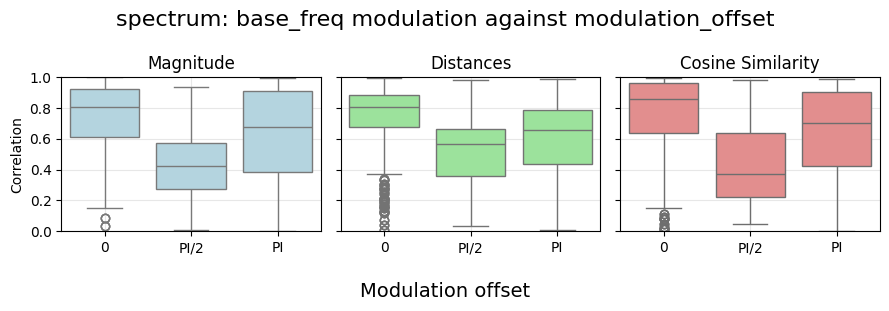

Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


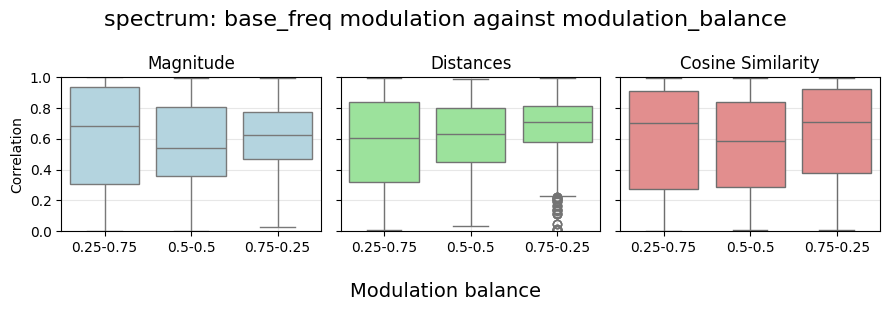

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


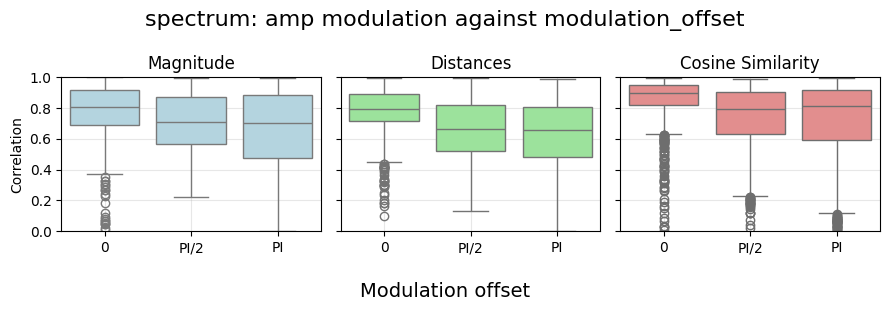

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


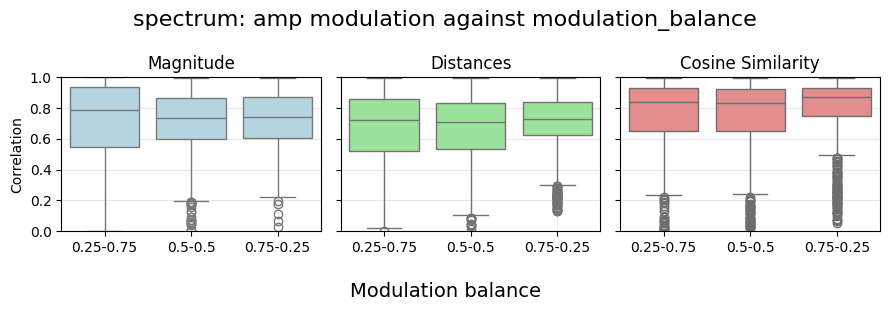

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


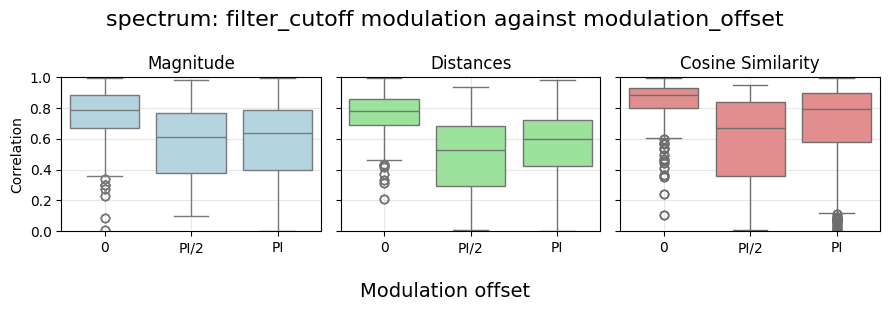

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


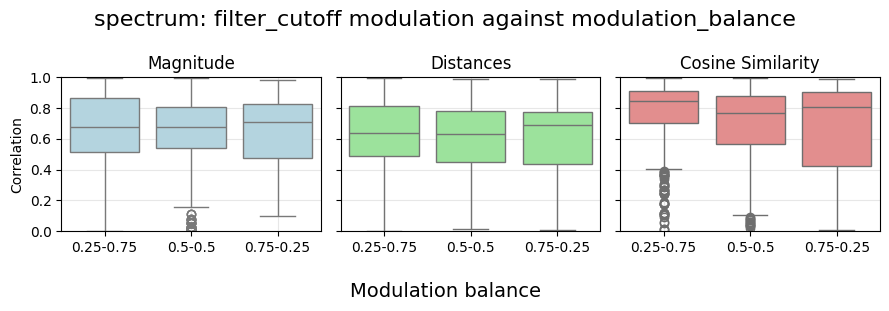

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


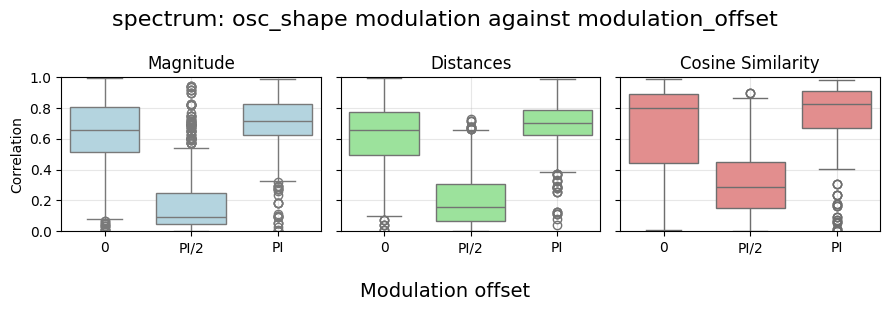

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


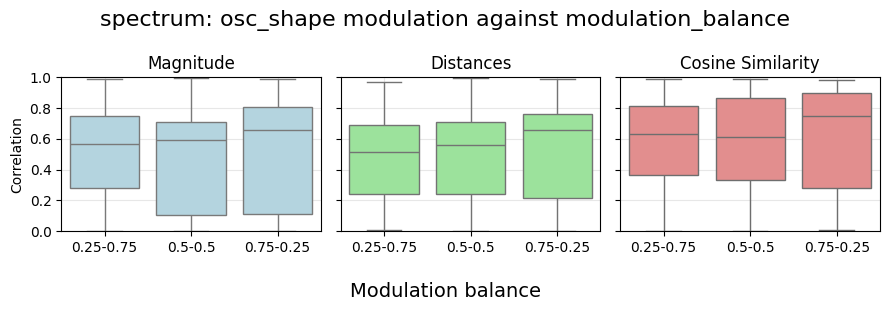

Plotting for dac
Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


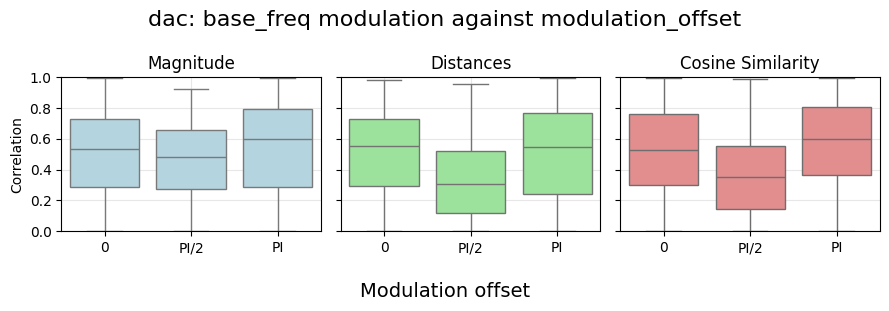

Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


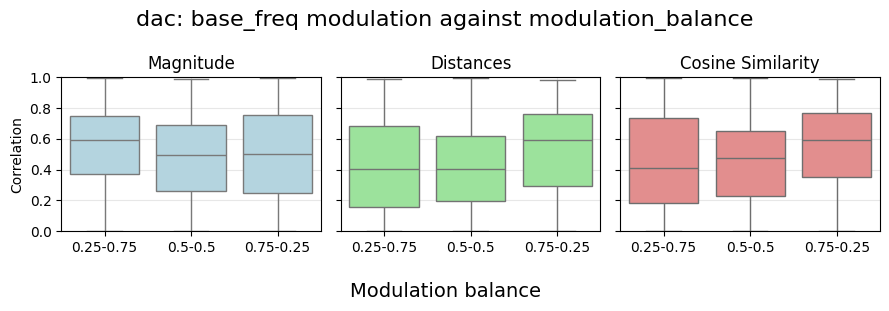

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


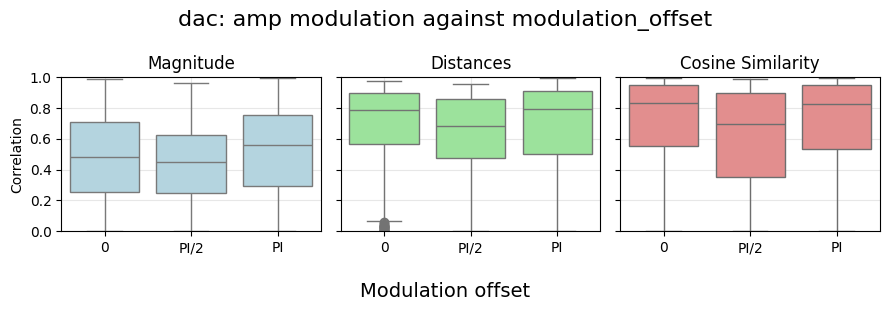

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


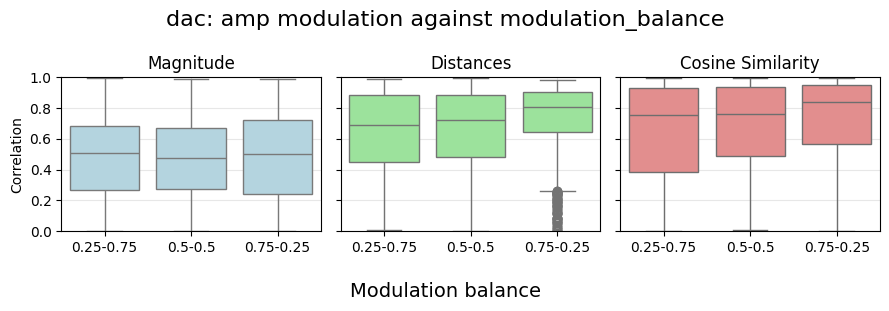

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


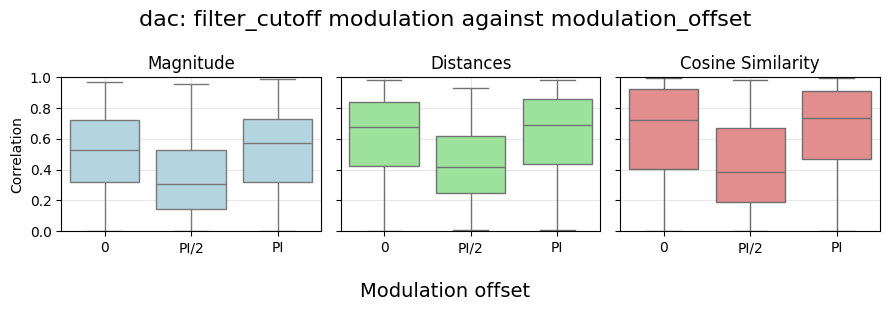

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


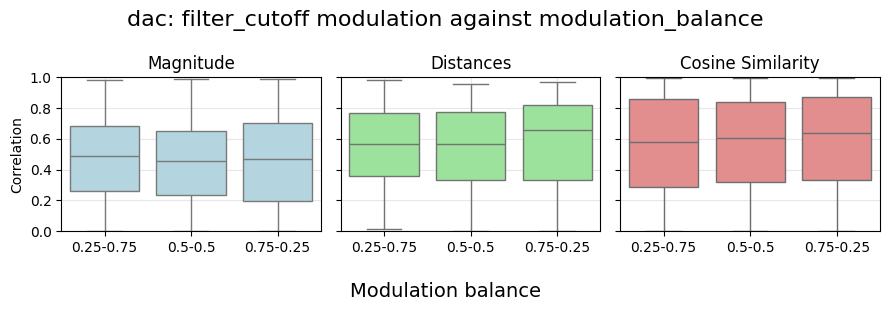

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


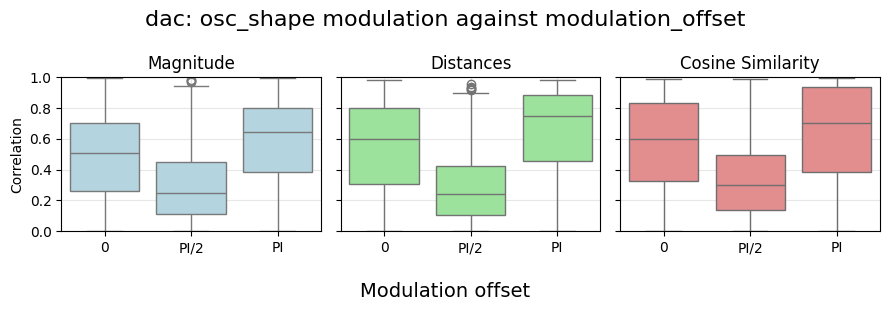

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


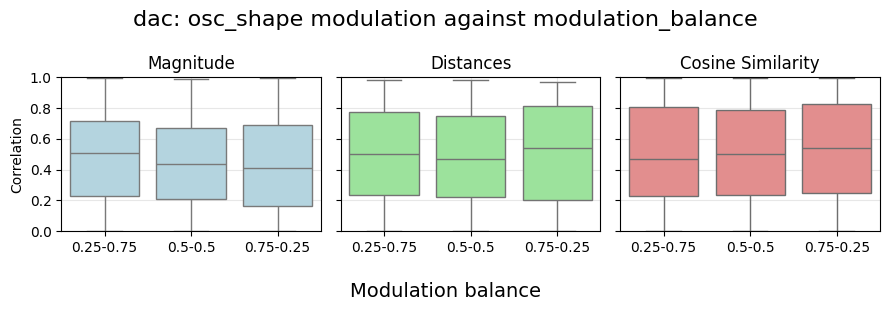

Plotting for music2latent
Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


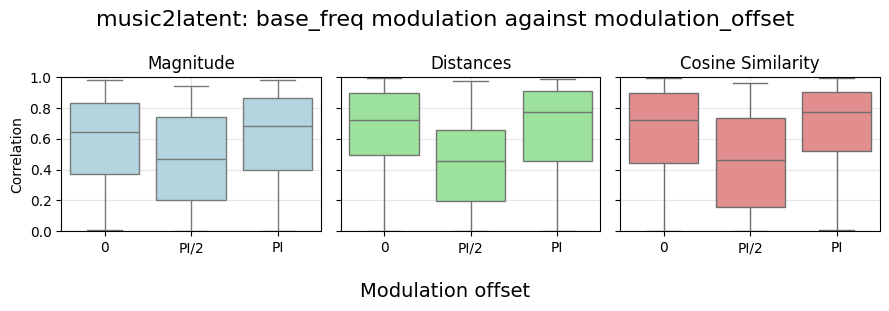

Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


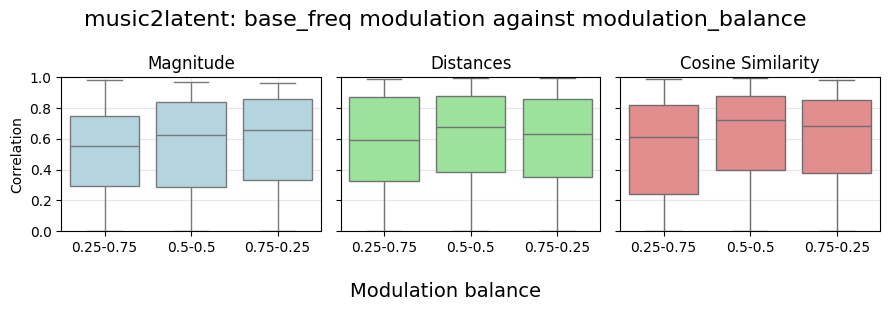

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


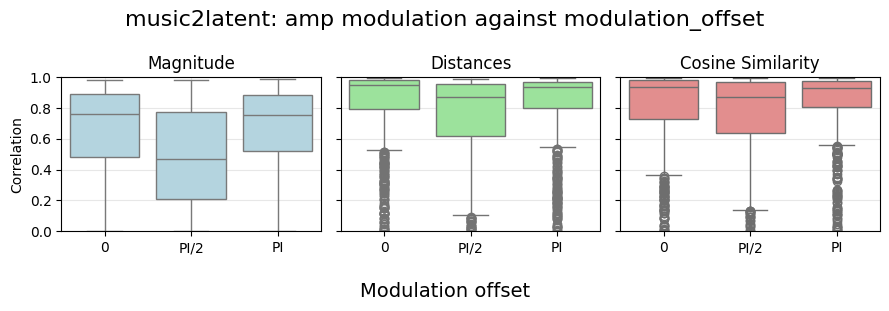

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


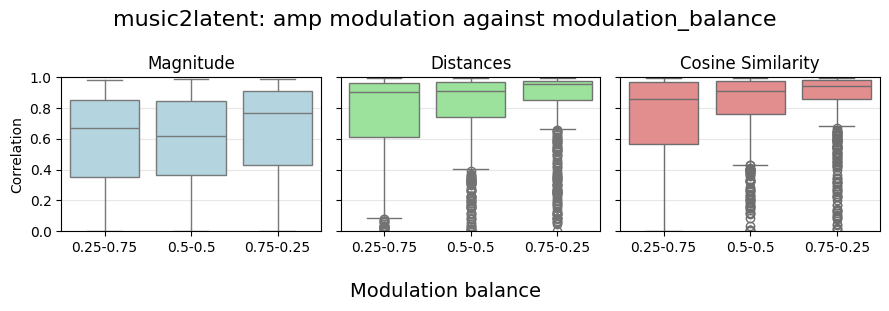

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


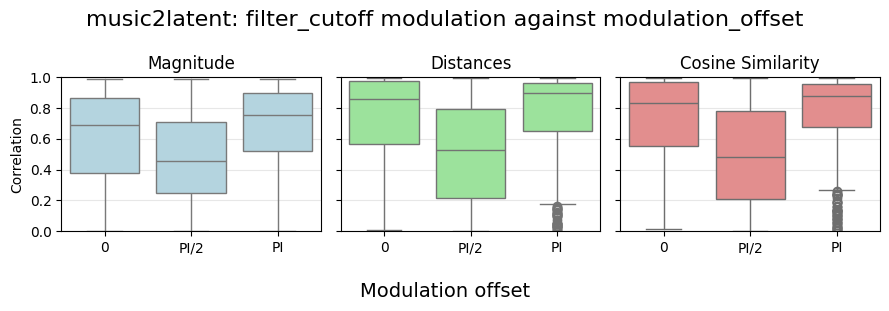

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


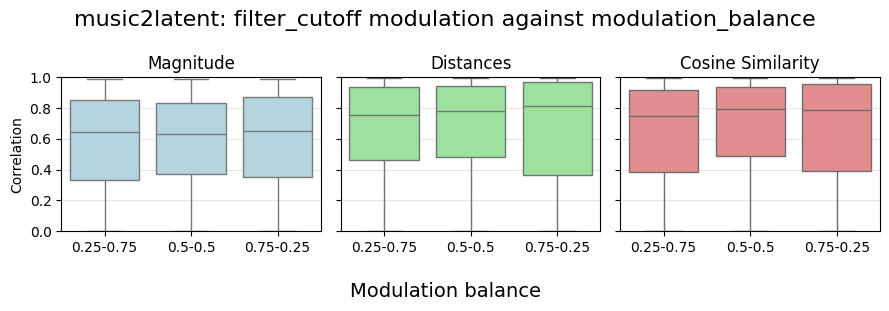

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


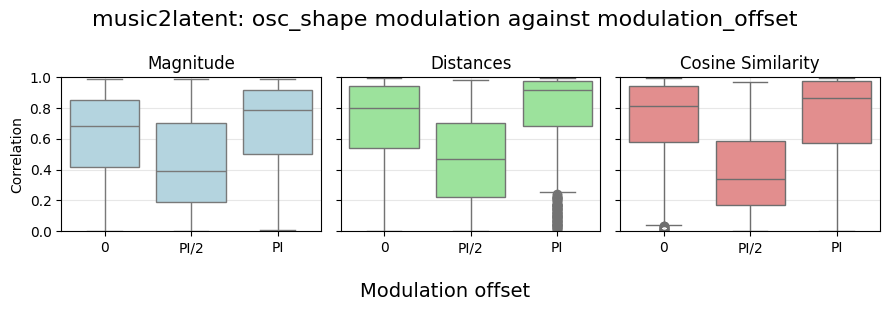

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


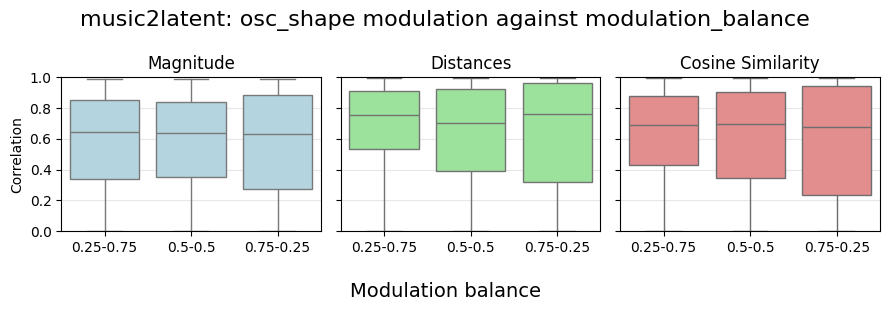

Plotting for cqt
Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


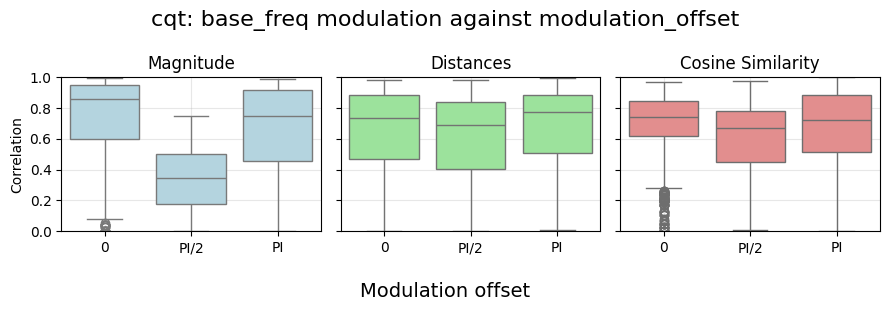

Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


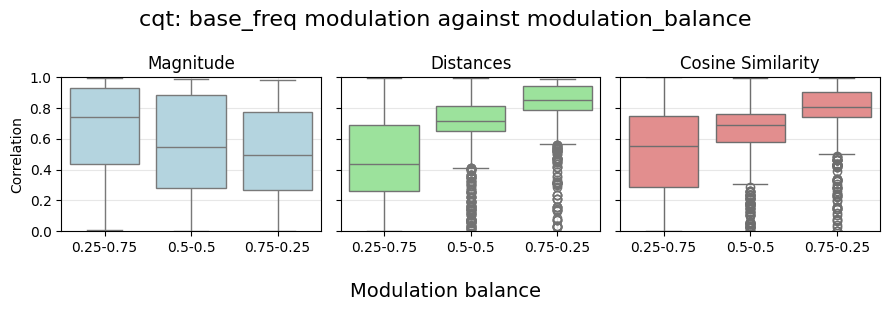

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


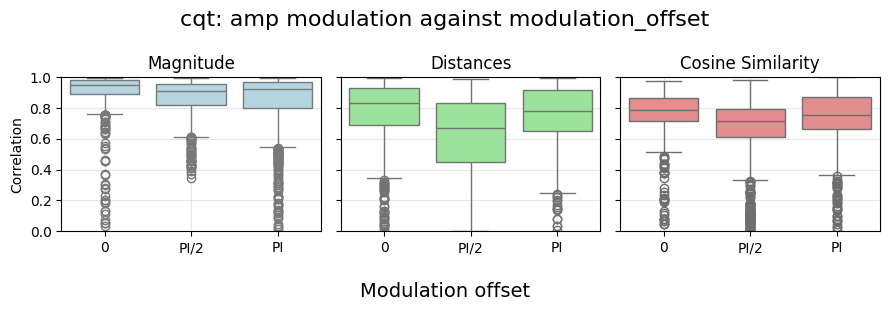

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


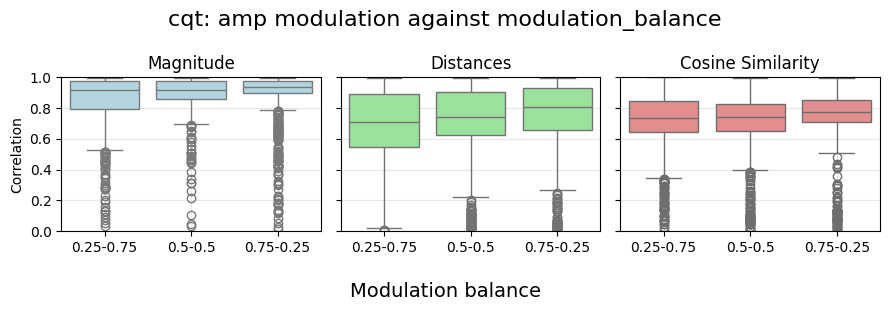

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


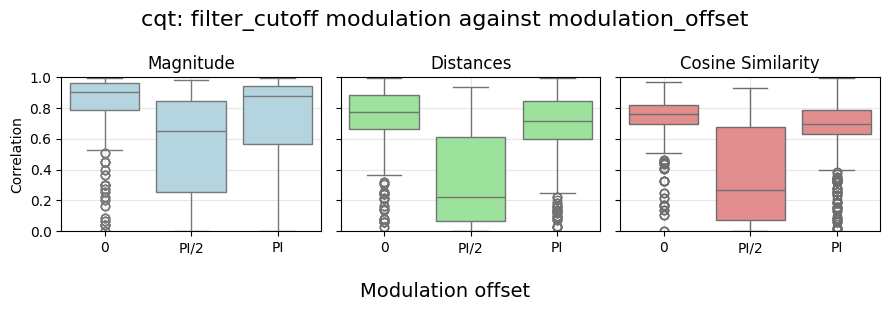

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


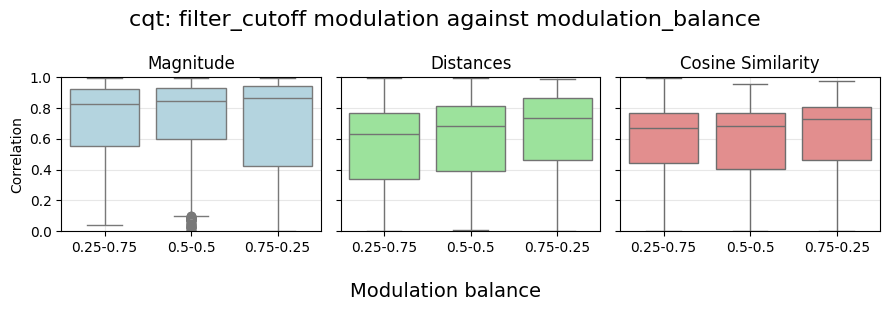

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


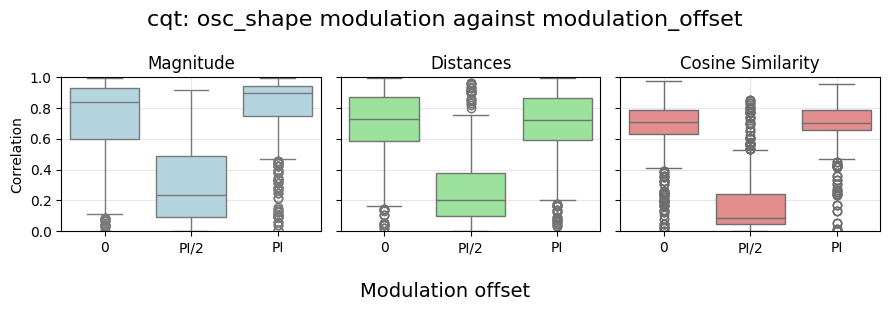

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


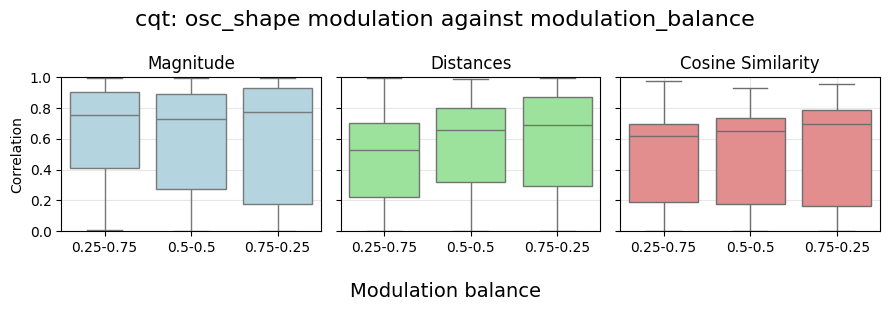

Plotting for mfcc
Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


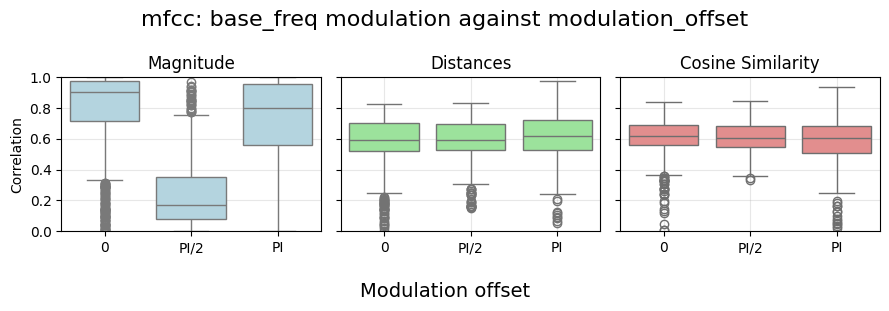

Index of base_freq in modulations: 0
Valid modulations for base_freq: [0, 1, 2]


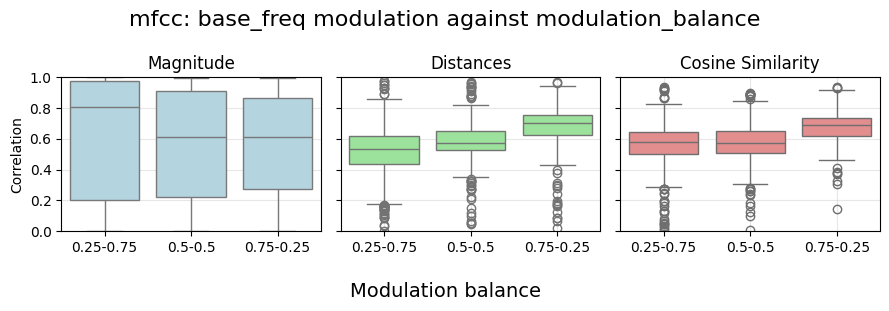

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


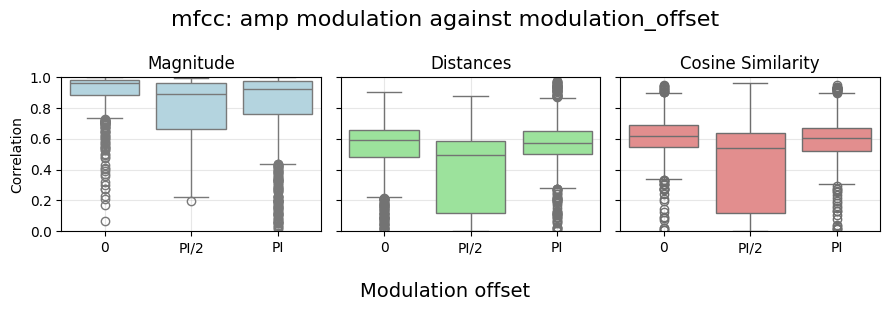

Index of amp in modulations: 1
Valid modulations for amp: [0, 3, 4]


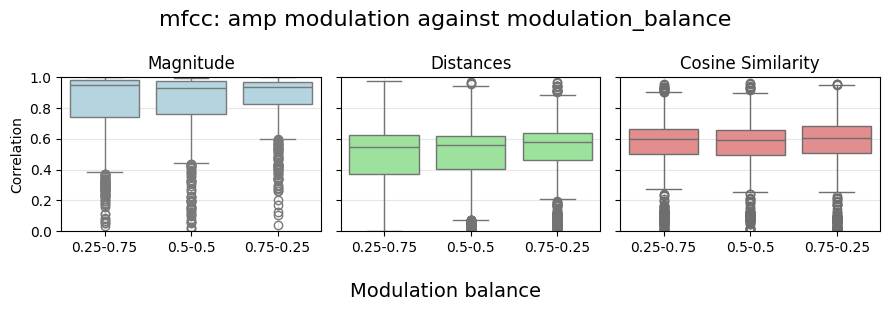

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


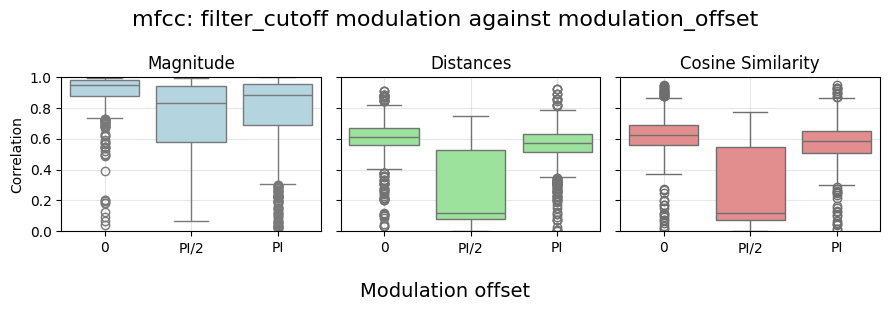

Index of filter_cutoff in modulations: 2
Valid modulations for filter_cutoff: [1, 3, 5]


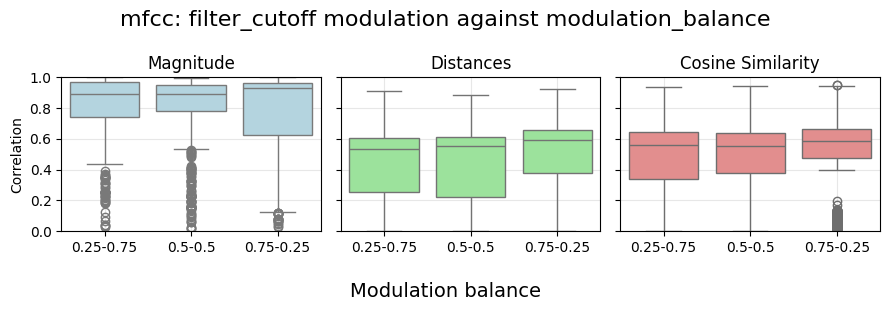

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


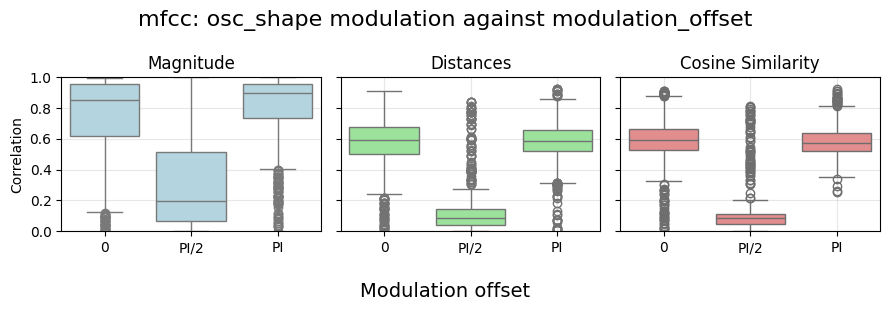

Index of osc_shape in modulations: 3
Valid modulations for osc_shape: [2, 4, 5]


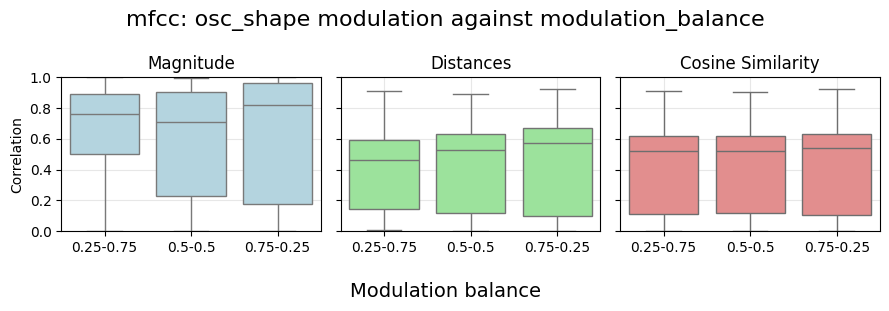

In [12]:
reprs = 'spectrum dac music2latent cqt mfcc'.split()
mod_targets = 'base_freq amp filter_cutoff osc_shape'.split()
xs = 'modulation_offset modulation_balance'.split()

for repr in reprs:
    print(f'Plotting for {repr}')
    for mod_target in mod_targets:
        for x in xs:
            plot_correlation_boxplots(df, repr, mod_target, x)